# Required Liberraies


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc


nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Exploration and Understanding


In [38]:
file_path = '/content/drive/My Drive/AI_Human_text_classification/Assignment 1 Data/AI_vs_huam_train_dataset.xlsx'

In [39]:
test_path = '/content/drive/My Drive/AI_Human_text_classification/Assignment 1 Data/Final_test_data.csv'
test_df = pd.read_csv(test_path)
test_texts = test_df['essay']

In [40]:
test_texts.head()

,essay
0,"Enjoyment means entertainment, satisfaction of..."
1,Before to start with my opinion of the topic i...
2,"Thats a really really good subject, but acctul..."
3,I disagree with the statement saying that it i...
4,It is undeniable that advertisements play a si...


In [41]:
df = pd.read_excel(file_path)
df.head()

,essay,label
0,International sports events require the most w...,0
1,Globalisation has become a significant aspect ...,0
2,There is an ever-increasing number of bullying...,0
3,"It is commonly believed, that companies should...",0
4,Despite knowing about the adverse effects of c...,0


In [42]:
total_samples = len(df)
print(f"Total Samples: {total_samples}")

Total Samples: 3728


In [43]:
classes = df['label'].nunique()
print(f"Number of Classes: {classes}")

Number of Classes: 2


In [44]:
class_distribution = df['label'].value_counts()
print("Class Distribution:\n", class_distribution)

Class Distribution:
 label
0    1864
1    1864
Name: count, dtype: int64


#### human-written sample

In [45]:
print(f"\nHuman-written Sample (label 0):\n {df[df['label'] == 0]['essay'].iloc[0]}")


Human-written Sample (label 0):
 International sports events require the most well-trained athletes for each country, in order to achieve this goal countries make an effort to build infrastructure designed to train top athletes. Although this policy can indeed make fewer sports facilities for ordinary people, investing in the best athletes is vital to develop competitive sports performances in each country.
On the one hand, building specific infrastructure for the best athletes is crucial in order to get better results at international sports events such as The Olympics or the World Cup. The importance of getting better results is that it creates awareness of the importance of sports in society and motivates more people to do a sport. In this way, investing in these developments can help countries to develop an integral sport policy that can benefit everyone.
On the other hand, one can argue that a negative effect could be that less infrastructure is built for the rest of the people. 

#### AI_written sample

In [46]:
print(f"\nAI-written Sample (label 1):\n {df[df['label'] == 1]['essay'].iloc[0]}")


AI-written Sample (label 1):
 International sports events demand that countries field their most highly trained athletes, which is why many nations invest in specialized facilities to help their top performers succeed. While this approach can sometimes mean fewer sports facilities are available for the general public, supporting elite athletes is essential for developing a country‚Äôs competitive edge in international competitions.

On one hand, constructing dedicated infrastructure for elite athletes is key to achieving better results at events like the Olympics or the World Cup. Success on the world stage not only raises awareness about the value of sports but also inspires more people to get involved in physical activities. In this sense, investing in top-level training can lead to broader sports development policies that ultimately benefit society as a whole.

On the other hand, some might argue that focusing on elite facilities limits access for everyday people. However, most peo

#### class distribution

<ipython-input-47-2722460216>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


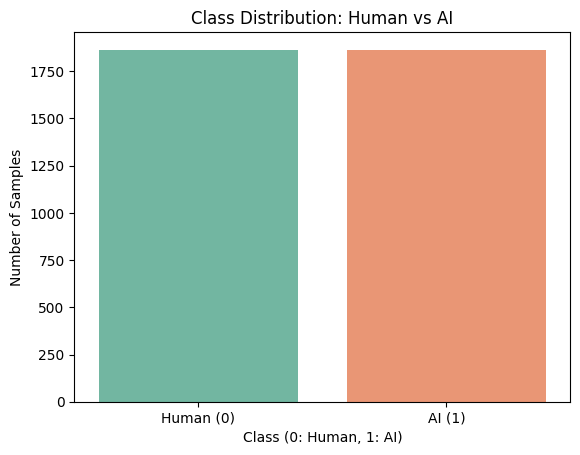

In [47]:
sns.countplot(data=df, x='label', palette='Set2')
plt.title("Class Distribution: Human vs AI")
plt.xlabel("Class (0: Human, 1: AI)")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ['Human (0)', 'AI (1)'])
plt.show()

# Text Preprocessing

### Stop Words Removal

In [48]:
nltk.download('punkt_tab')
sample_text = df['essay'].iloc[0]

# Tokenize and remove stop words
words = word_tokenize(sample_text.lower())
filtered_words = [word for word in words if word.isalpha() and word not in stopwords.words('english')]

print("Original Text:\n", sample_text)
print("\nAfter Stop Word Removal:\n", ' '.join(filtered_words))

Original Text:
 International sports events require the most well-trained athletes for each country, in order to achieve this goal countries make an effort to build infrastructure designed to train top athletes. Although this policy can indeed make fewer sports facilities for ordinary people, investing in the best athletes is vital to develop competitive sports performances in each country.
On the one hand, building specific infrastructure for the best athletes is crucial in order to get better results at international sports events such as The Olympics or the World Cup. The importance of getting better results is that it creates awareness of the importance of sports in society and motivates more people to do a sport. In this way, investing in these developments can help countries to develop an integral sport policy that can benefit everyone.
On the other hand, one can argue that a negative effect could be that less infrastructure is built for the rest of the people. However, people wh

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [49]:
original_vocab = set(word_tokenize(' '.join(df['essay']).lower()))
original_vocab = {word for word in original_vocab if word.isalpha()}

# filtered vocab
stop_words = set(stopwords.words('english'))
filtered_vocab = {word for word in original_vocab if word not in stop_words}

print("\nOriginal Vocabulary Size:", len(original_vocab))
print("Filtered Vocabulary Size:", len(filtered_vocab))


Original Vocabulary Size: 20425
Filtered Vocabulary Size: 20279


### Stemming Techniques

In [50]:
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lancaster = LancasterStemmer()

In [51]:
words = ['running', 'flies', 'better', 'studies', 'organization', 'caring', 'connection']

# Create a table of stemmed versions
print("{:<15} {:<15} {:<15} {:<15}".format("Original", "Porter", "Snowball", "Lancaster"))
print("-" * 60)
for word in words:
    print("{:<15} {:<15} {:<15} {:<15}".format(
        word,
        porter.stem(word),
        snowball.stem(word),
        lancaster.stem(word)
    ))

Original        Porter          Snowball        Lancaster      
------------------------------------------------------------
running         run             run             run            
flies           fli             fli             fli            
better          better          better          bet            
studies         studi           studi           study          
organization    organ           organ           org            
caring          care            care            car            
connection      connect         connect         connect        


In [52]:
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [53]:
print("\n{:<15} {:<20} {:<20}".format("Original", "WordNet Lemma", "spaCy Lemma"))
print("-" * 55)

for word in words:
    spacy_lemma = nlp(word)[0].lemma_
    print("{:<15} {:<20} {:<20}".format(word, lemmatizer.lemmatize(word), spacy_lemma))



Original        WordNet Lemma        spaCy Lemma         
-------------------------------------------------------
running         running              run                 
flies           fly                  fly                 
better          better               well                
studies         study                study               
organization    organization         organization        
caring          caring               care                
connection      connection           connection          


In [54]:
data = {
    'Original': words,
    'Porter Stemmer': [porter.stem(w) for w in words],
    'Snowball Stemmer': [snowball.stem(w) for w in words],
    'Lancaster Stemmer': [lancaster.stem(w) for w in words],
    'WordNet Lemma': [lemmatizer.lemmatize(w) for w in words],
    'spaCy Lemma': [nlp(w)[0].lemma_ for w in words]
}

df_table = pd.DataFrame(data)
df_table

,Original,Porter Stemmer,Snowball Stemmer,Lancaster Stemmer,WordNet Lemma,spaCy Lemma
0,running,run,run,run,running,run
1,flies,fli,fli,fli,fly,fly
2,better,better,better,bet,better,well
3,studies,studi,studi,study,study,study
4,organization,organ,organ,org,organization,organization
5,caring,care,care,car,caring,care
6,connection,connect,connect,connect,connection,connection


In [55]:
nlp = spacy.load("en_core_web_sm")

# Load the first paragraph/text
original_text = df['essay'].iloc[0]

# Tokenize and lowercase
tokens = word_tokenize(original_text.lower())
tokens = [word for word in tokens if word.isalpha()]  # keep only alphabetic tokens

# Remove stop words
stop_words = set(stopwords.words('english'))
no_stopwords = [word for word in tokens if word not in stop_words]

# Initialize stemmers and lemmatizers
porter = PorterStemmer()
snowball = SnowballStemmer("english")
lancaster = LancasterStemmer()
wordnet = WordNetLemmatizer()

# Apply each transformation
stopword_removed_text = ' '.join(no_stopwords)
porter_text = ' '.join([porter.stem(word) for word in no_stopwords])
snowball_text = ' '.join([snowball.stem(word) for word in no_stopwords])
lancaster_text = ' '.join([lancaster.stem(word) for word in no_stopwords])
wordnet_text = ' '.join([wordnet.lemmatize(word) for word in no_stopwords])
spacy_text = ' '.join([token.lemma_ for token in nlp(' '.join(no_stopwords))])

# Build comparison table
comparison_table = pd.DataFrame({
    'Technique': [
        'Original Text',
        'Stop Words Removed',
        'Porter Stemmer',
        'Snowball Stemmer',
        'Lancaster Stemmer',
        'WordNet Lemmatizer',
        'spaCy Lemmatizer'
    ],
    'Transformed Text': [
        original_text,
        stopword_removed_text,
        porter_text,
        snowball_text,
        lancaster_text,
        wordnet_text,
        spacy_text
    ]
})

# Display the table
comparison_table

,Technique,Transformed Text
0,Original Text,International sports events require the most w...
1,Stop Words Removed,international sports events require athletes c...
2,Porter Stemmer,intern sport event requir athlet countri order...
3,Snowball Stemmer,intern sport event requir athlet countri order...
4,Lancaster Stemmer,intern sport ev requir athlet country ord achi...
5,WordNet Lemmatizer,international sport event require athlete coun...
6,spaCy Lemmatizer,international sport event require athlete coun...


## For Test_set


### Stop Words Removal

In [56]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))


original_text = test_df['essay'].iloc[0]
tokens = word_tokenize(original_text.lower())
filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

print("Original:", original_text)
print("After Stop Word Removal:", ' '.join(filtered_tokens))
print("Original Vocab Size:", len(set(tokens)))
print("After Stopword Removal Vocab Size:", len(set(filtered_tokens)))

Original: Enjoyment means entertainment, satisfaction of one's soul and containment with the happenings in life. I would like to disagree with this statement. This is because entertainment would mean differently to different people. Entertainment depends on various factors like the person's attitude and his notion or perspective on entertainment.
   The younger generation tends to enjoy themselves by going to parties, meeting new people, making new friends and going for long drives. The way a youngster enjoys himself or herself depends on the attitude and nature of the individual. Some people might like to go to parties for entertainment while others might like to watch a movie.
   On the other hand the older people might also do the same things that youngsters do or they may engage in activities considered as dull and boring by the youngsters. I would like to take examples of two famous personalities here who despite their age never complained of boredom. Firstly, I would like to take

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Stemming Techniques

In [57]:
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lancaster = LancasterStemmer()

porter_stemmed = [porter.stem(w) for w in filtered_tokens]
snowball_stemmed = [snowball.stem(w) for w in filtered_tokens]
lancaster_stemmed = [lancaster.stem(w) for w in filtered_tokens]


### Lemmatization



In [58]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


###  Table for Comparison

In [59]:
comparison_df = pd.DataFrame({
    "Original": filtered_tokens,
    "Porter Stemmer": porter_stemmed,
    "Snowball Stemmer": snowball_stemmed,
    "Lancaster Stemmer": lancaster_stemmed,
    "Lemmatized": lemmatized
})

comparison_df.head(10)

,Original,Porter Stemmer,Snowball Stemmer,Lancaster Stemmer,Lemmatized
0,enjoyment,enjoy,enjoy,enjoy,enjoyment
1,means,mean,mean,mean,mean
2,entertainment,entertain,entertain,entertain,entertainment
3,satisfaction,satisfact,satisfact,satisfact,satisfaction
4,one,one,one,on,one
5,soul,soul,soul,soul,soul
6,containment,contain,contain,contain,containment
7,happenings,happen,happen,hap,happening
8,life,life,life,lif,life
9,would,would,would,would,would


# Feature Extraction

In [60]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to entire dataset

test_df['preprocessed_text'] = test_df['essay'].apply(preprocess_text)
df['preprocessed_text'] = df['essay'].apply(preprocess_text)

## For training set

### TF-IDF Vectorizer: unigrams, bigrams, trigrams

In [61]:
tfidf_uni = TfidfVectorizer(ngram_range=(1,1), max_features=5000, min_df=5, max_df=0.7)
X_tfidf_uni = tfidf_uni.fit_transform(df['preprocessed_text'])

print("TF-IDF Unigrams shape:", X_tfidf_uni.shape)

TF-IDF Unigrams shape: (3728, 5000)


In [62]:
tfidf_bi = TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=5, max_df=0.7)
X_tfidf_bi = tfidf_bi.fit_transform(df['preprocessed_text'])

print("TF-IDF Unigrams + Bigrams shape:", X_tfidf_bi.shape)

TF-IDF Unigrams + Bigrams shape: (3728, 5000)


In [63]:
count_uni = CountVectorizer(ngram_range=(1,1), max_features=5000, min_df=5, max_df=0.7)
X_count_uni = count_uni.fit_transform(df['preprocessed_text'])

print("Count Vectorizer Unigrams shape:", X_count_uni.shape)

Count Vectorizer Unigrams shape: (3728, 5000)


In [64]:
tfidf_tri = TfidfVectorizer(ngram_range=(1,3), max_features=5000, min_df=5, max_df=0.7)
X_tfidf_tri = tfidf_tri.fit_transform(df['preprocessed_text'])

print("TF-IDF Unigrams + Bigrams + Trigrams shape:", X_tfidf_tri.shape)

TF-IDF Unigrams + Bigrams + Trigrams shape: (3728, 5000)


In [65]:
print("TF-IDF shapes:")
print("Unigrams:", X_tfidf_uni.shape)
print("Bigrams:", X_tfidf_bi.shape)
print("Trigrams:", X_tfidf_tri.shape)

print("\nCount Vectorizer shape:")
print("Unigrams:", X_count_uni.shape)

TF-IDF shapes:
Unigrams: (3728, 5000)
Bigrams: (3728, 5000)
Trigrams: (3728, 5000)

Count Vectorizer shape:
Unigrams: (3728, 5000)


## For Test Set

In [66]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000, min_df=5, max_df=0.8)
tfidf_vectorizer.fit(df['preprocessed_text'])

X_test_final_tfidf = tfidf_vectorizer.transform(test_df['preprocessed_text'])

In [67]:
bow_vectorizer = CountVectorizer(ngram_range=(1,2), max_features=5000, min_df=5, max_df=0.8)
bow_vectorizer.fit(df['preprocessed_text'])

X_test_final_bow = bow_vectorizer.transform(test_df['preprocessed_text'])

In [68]:
from sklearn.model_selection import train_test_split
X = X_tfidf_uni
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
def plot_conf_matrix(y_true, y_pred, title, color='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False,
                xticklabels=['Human (0)', 'AI (1)'],
                yticklabels=['Human (0)', 'AI (1)'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()

### SVM

In [79]:
def classification_report_to_df(y_true, y_pred):
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    return df_report

### Decision Tree

In [ ]:
df_gini_report = classification_report_to_df(y_test, y_pred_gini)
print("Decision Tree (Gini) Report:")
display(df_gini_report)

# Entropy Criterion
df_entropy_report = classification_report_to_df(y_test, y_pred_entropy)
print("Decision Tree (Entropy) Report:")
display(df_entropy_report)


In [ ]:
plot_conf_matrix(y_test, y_pred_gini, title="Decision Tree (Gini)", color="YlOrBr")
plot_conf_matrix(y_test, y_pred_entropy, title="Decision Tree (Entropy)", color="YlOrBr")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (Macro)": recall_score(y_true, y_pred, average='macro'),
        "F1-score (Macro)": f1_score(y_true, y_pred, average='macro'),
        "Precision (Weighted)": precision_score(y_true, y_pred, average='weighted'),
        "Recall (Weighted)": recall_score(y_true, y_pred, average='weighted'),
        "F1-score (Weighted)": f1_score(y_true, y_pred, average='weighted'),
    }

In [ ]:
metrics = {
    "SVM (Linear)": get_metrics(y_test, y_pred_linear),
    "SVM (RBF)": get_metrics(y_test, y_pred_rbf),
    "DT (Gini)": get_metrics(y_test, y_pred_gini),
    "DT (Entropy)": get_metrics(y_test, y_pred_entropy),
}

df_metrics = pd.DataFrame(metrics).T.round(3)
display(df_metrics.style.set_caption("Performance Comparison Table"))

In [ ]:
def plot_roc_curve(models, model_names, X_test, y_test):
    plt.figure(figsize=(8, 6))

    for model, name in zip(models, model_names):
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
models = [svm_linear, svm_rbf, dt_gini, dt_entropy]
names = ["SVM (Linear)", "SVM (RBF)", "DT (Gini)", "DT (Entropy)"]
plot_roc_curve(models, names, X_test, y_test)


In [ ]:
def analyze_errors(y_true, y_pred, X_raw_text, label=0):
    errors = (y_true != y_pred)
    misclassified_df = pd.DataFrame({
        'Actual': y_true,
        'Predicted': y_pred,
        'Text': X_raw_text
    })[errors]

    print(f"Total misclassified samples: {len(misclassified_df)}")
    return misclassified_df

In [ ]:
X_raw = df['essay']
y = df['label']


X_raw_train, X_raw_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

misclassified_linear = analyze_errors(y_test, y_pred_linear, X_raw_test)
display(misclassified_linear.head())

# Prediction Results

In [ ]:
X_train_tfidf = tfidf_vectorizer.fit_transform(df['preprocessed_text'])
y_train = df['label']

if 'essay_id' not in test_df.columns:
    test_df['essay_id'] = range(1, len(test_df) + 1)


from sklearn.svm import SVC
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_tfidf, y_train)

y_test_predictions = svm_linear.predict(X_test_final_tfidf)


test_df['predicted_label'] = y_test_predictions

final_output = test_df[['essay_id', 'predicted_label']]

final_output.to_csv('final_test_predictions.csv', index=False)

print("✅ Predictions saved to 'final_test_predictions.csv'")